# HOMEWORK 13

In this homework you are going to build your first classifier for the CIFAR-10 dataset. This dataset contains 10 different classes and you can learn more about it [here](https://www.cs.toronto.edu/~kriz/cifar.html). This homework consists of the following tasks:
* Dataset inspection
* Building the network
* Training
* Evaluation

At the end, as usual, there will be a couple of questions for you to answer :-)

In [34]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D
from tensorflow.keras import Model
from time import time

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 42
seed(seed_value)
set_seed(seed_value)

### Step 0: Dataset Inspection

Load the dataset and make a quick inspection.

Dataset: 50000 train samples, 10000 test samples


/var/folders/m6/lyw4xkxs51x5n89xj442j5bc0000gn/T/ipykernel_27540/745173097.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(classes[int(y_train[idx])])


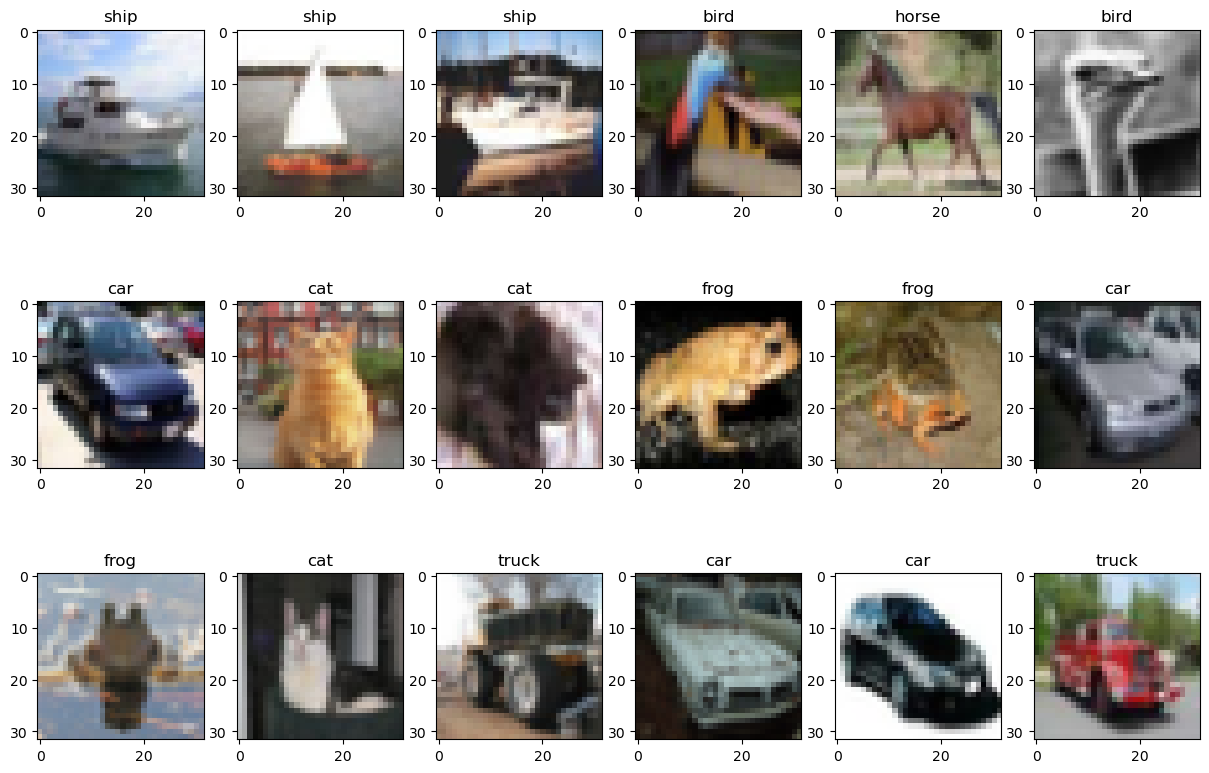

In [35]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Mapping from class ID to class name
classes = {0:'plane', 1:'car', 2:'bird', 3:'cat', 4:'deer',
           5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}

# Dataset params
num_classes = len(classes)
size = x_train.shape[1]
print(f"Dataset: {x_train.shape[0]} train samples, {x_test.shape[0]} test samples")

# Visualize random samples (as a plot with 3x6 samples)
for ii in range(18):
    plt.subplot(3,6,ii+1)
    # Pick a random sample
    idx = np.random.randint(0, x_train.shape[0])
    # Show the image and the label
    plt.imshow(x_train[idx])
    plt.title(classes[int(y_train[idx])])

Compute the class histogram (you can visualize it if you want). Is the dataset balanced?

Hint: You might find [Counter](https://docs.python.org/3/library/collections.html#collections.Counter) tool useful. In any case, it's up to you how you compute the histogram.

Counter({6: 5000, 9: 5000, 4: 5000, 1: 5000, 2: 5000, 7: 5000, 8: 5000, 3: 5000, 5: 5000, 0: 5000})


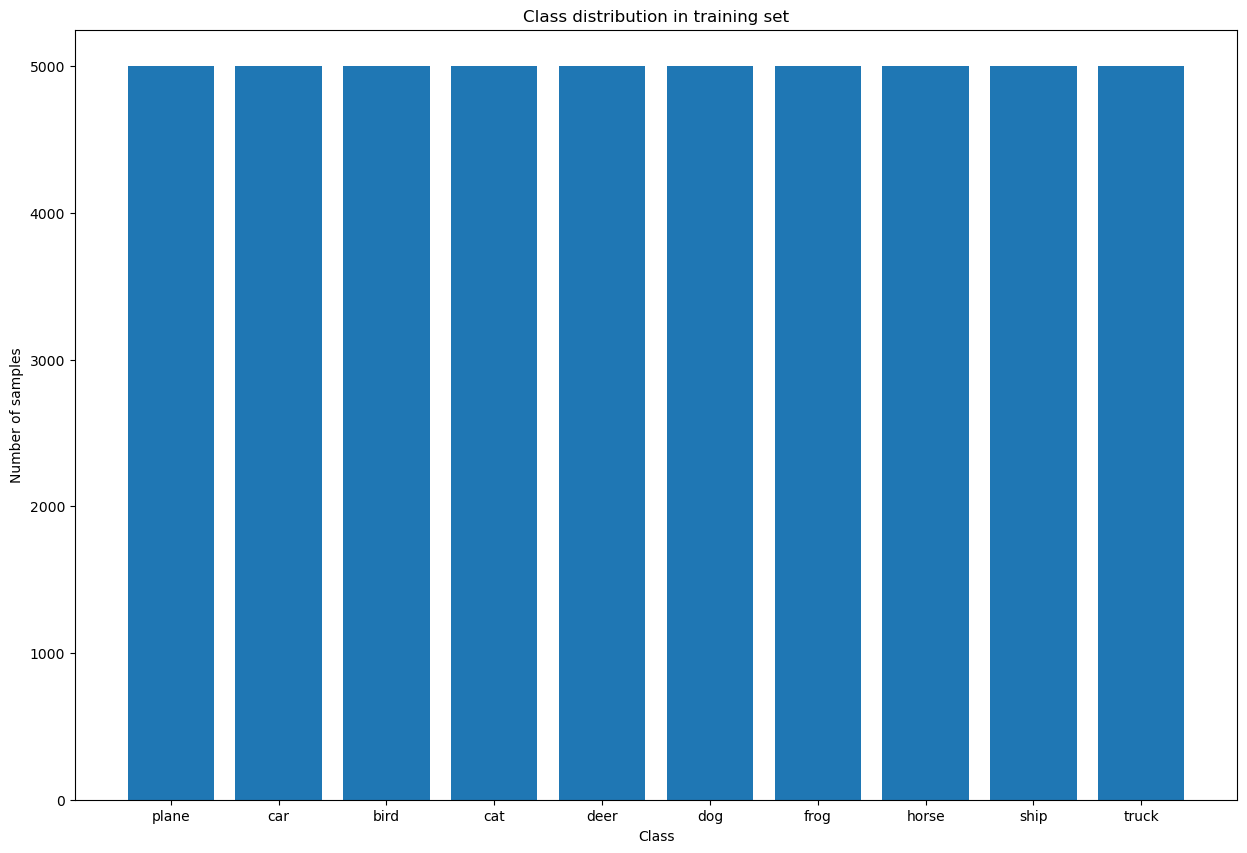

In [36]:
from collections import Counter

hist = Counter(y_train.flatten())
print(hist)
plt.bar(hist.keys(), hist.values())
plt.xticks(list(classes.keys()), list(classes.values()))
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.title('Class distribution in training set')
plt.show()

### Step 1: Data Preparation

In this step, you'll need to prepare the data for training, i.e., you will have to normalize it and encode the labels as one-hot vectors.

In [37]:
# Normalization
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

# One-hot encoding
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes)

print(f'Train shape: {y_train_cat.shape} samples')
print(f'Test shape: {y_test_cat.shape} samples')
print(f'X shape: {x_train_norm.shape}')

Train shape: (50000, 10) samples
Test shape: (10000, 10) samples
X shape: (50000, 32, 32, 3)


### Step 2: Building the Classifier

Build the CNN for CIFAR10 classification. For starters, you can use the same network we used in the lesson for the MNIST problem.

In [38]:
# Build the classifier
inputs = Input(shape=(size, size, 3))

net = Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same')(inputs)
net = Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same')(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Conv2D(64, kernel_size=(3, 3), activation="relu", padding='same')(net)
net = Conv2D(64, kernel_size=(3, 3), activation="relu", padding='same')(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Conv2D(128, kernel_size=(3, 3), activation="relu", padding='same')(net)
net = Conv2D(128, kernel_size=(3, 3), activation="relu", padding='same')(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Flatten()(net)
outputs = Dense(num_classes, activation="softmax")(net)

model = Model(inputs, outputs)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 307,498 (1.17 MB)

 Trainable params: 307,498 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

### Step 3: Training

Compile the model and train it.

In [39]:
epochs = 25
batch_size = 128

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

# I have special kind of pain - I'm running this on a MacBook with M1 Pro chip
# I'm unable to wait for tensorflow-cpu finishes at least one epoch
# So I'm tried tensorflow-metal here, by downgrading tensorflow to 2.16.0, and fit took about 7s per epoch
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
history = model.fit(x_train_norm, y_train_cat, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Num GPUs Available: 1
Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.4195 - loss: 1.5874 - val_accuracy: 0.5696 - val_loss: 1.2005
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.6141 - loss: 1.0911 - val_accuracy: 0.6716 - val_loss: 0.9472
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.6915 - loss: 0.8886 - val_accuracy: 0.7002 - val_loss: 0.8775
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.7365 - loss: 0.7594 - val_accuracy: 0.7304 - val_loss: 0.7989
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.7727 - loss: 0.6558 - val_accuracy: 0.7460 - val_loss: 0.7586
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.8004 - loss: 0.5800 - val_accuracy: 0.7440 - val_loss: 0.7524
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.8153 - loss: 0.5332 - val_accuracy: 0.7492 - val_loss: 0.7505
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.8

Train Acc      0.9680888652801514
Validation Acc 0.743399977684021


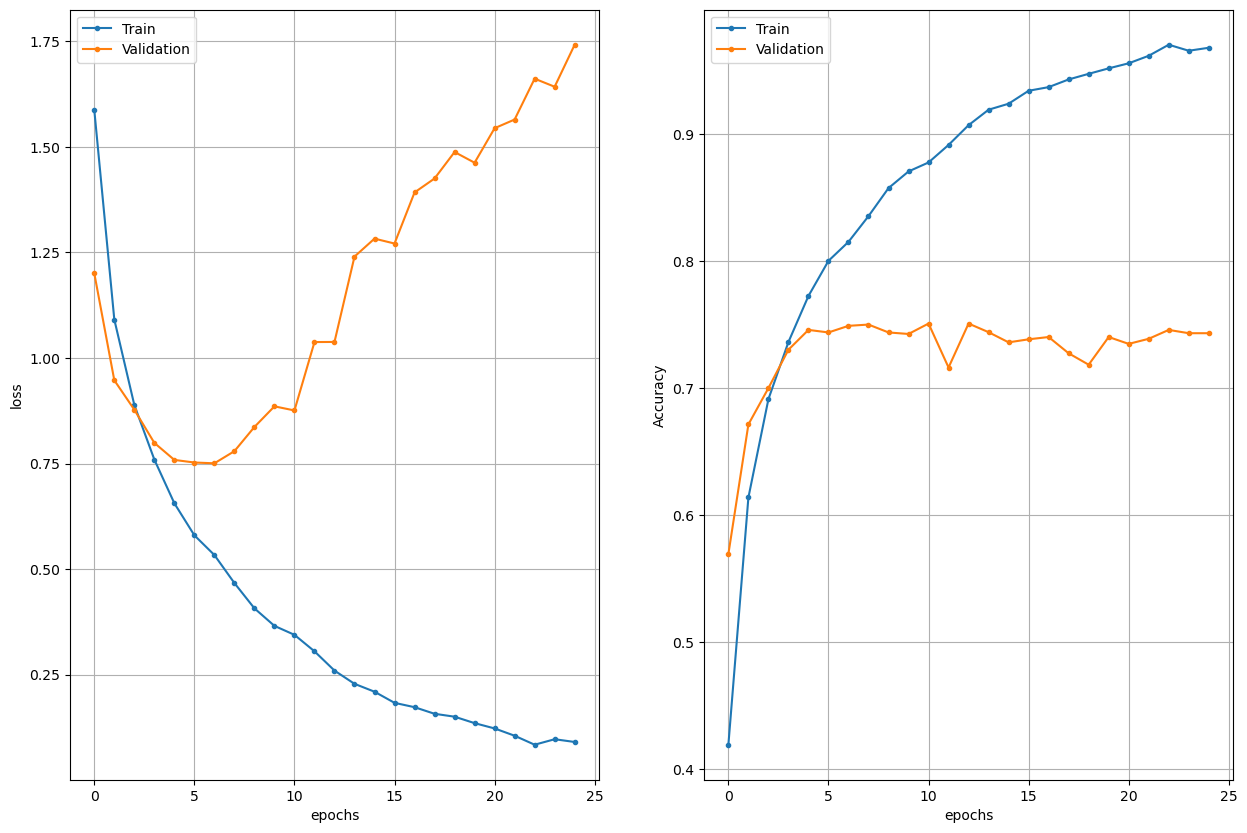

In [40]:
# Show training history (this cell is complete, nothing to implement here :-) )
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])

### Step 4: Evaluation

In this step, you have to calculate the accuracies and visualize some random samples. For the evaluation, you are going to use the test split from the dataset.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


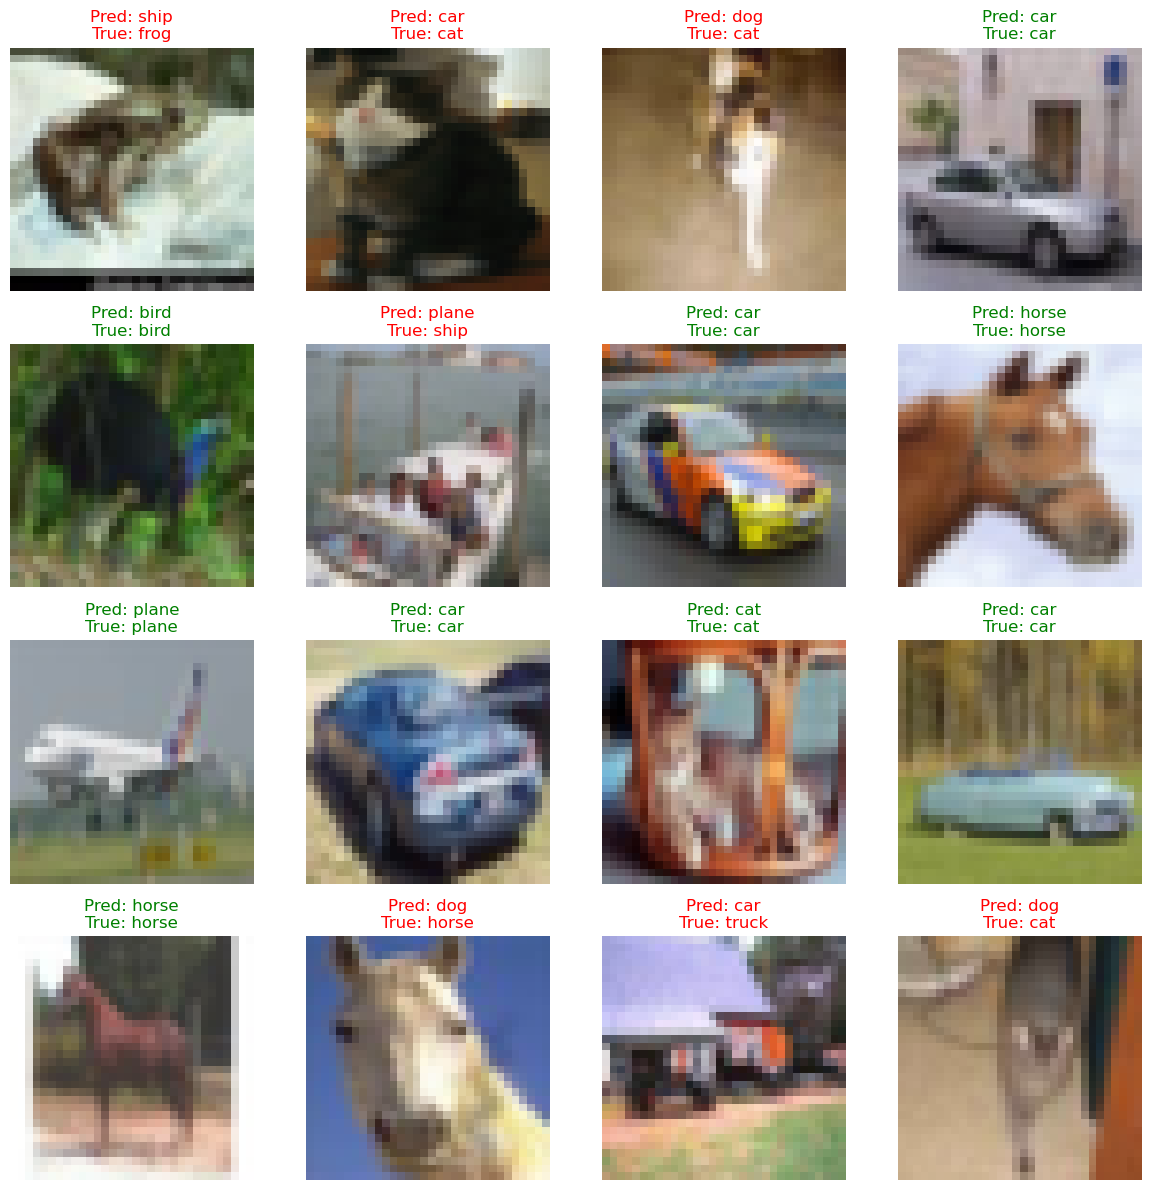

In [45]:
y_pred_probs = model.predict(x_test)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_test_cat, axis=1)

plt.figure(figsize=(12, 12))

for i in range(16):
    plt.subplot(4, 4, i + 1)

    idx = np.random.randint(0, x_test.shape[0])

    image = x_test[idx]
    pred_label_index = y_pred_labels[idx]
    true_label_index = y_true_labels[idx]

    title = f'Pred: {classes[pred_label_index]}\nTrue: {classes[true_label_index]}'
    color = 'green' if pred_label_index == true_label_index else 'red'

    plt.axis('off')
    plt.imshow(image)
    plt.title(title, color=color)

plt.tight_layout()
plt.show()

In [46]:
# Compute and print the accuracy for each class
for i in range(num_classes):
    class_name = classes[i]
    true_mask = (y_true_labels == i)
    pred_mask = (y_pred_labels == i)
    total_count = np.sum(true_mask)
    correct_count = np.sum(true_mask & pred_mask)
    accuracy = correct_count / total_count
    print(f'{class_name:<10}: {accuracy * 100:.2f}%')


plane     : 82.20%
car       : 88.80%
bird      : 44.80%
cat       : 32.30%
deer      : 34.50%
dog       : 60.40%
frog      : 68.20%
horse     : 84.00%
ship      : 76.10%
truck     : 77.70%


In [47]:
# Print the overall stats
ev = model.evaluate(x_test, y_test_cat)
print('Test loss  ', ev[0])
print('Test metric', ev[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6490 - loss: 446.5988
Test loss   446.5987854003906
Test metric 0.6489999890327454


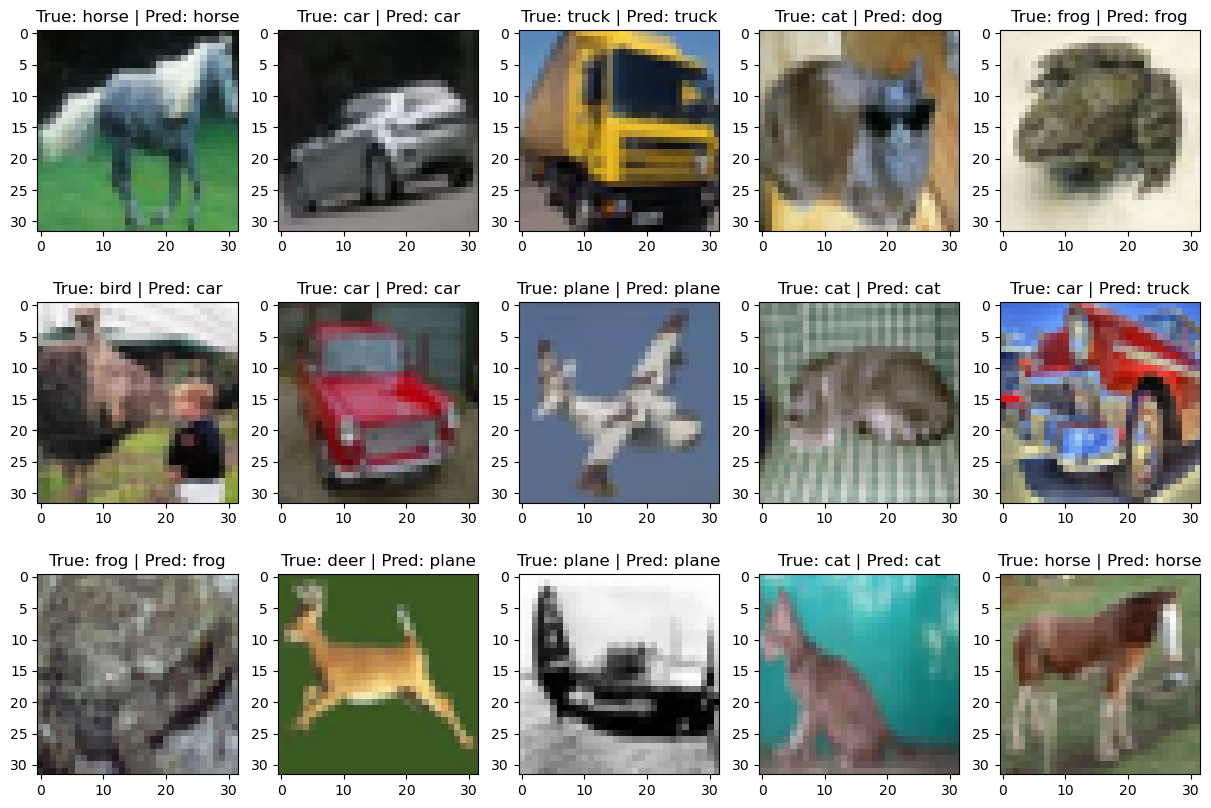

In [48]:
# Show random samples
for ii in range(15):
    # Pick a random sample
    idx = np.random.randint(0, x_test.shape[0])
    # Get the predicted class
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = y_test.flatten()
    # Show the results
    plt.subplot(3,5,ii+1), plt.imshow(x_test[idx, ...])
    plt.title('True: ' + str(classes[y_true[idx]]) + ' | Pred: ' + str(classes[y_pred[idx]]))

### Questions
* What is the overall accuracy of the classifier?

    First attempt: accuracy 52%. Incredible low. Also, I'm confused why loss is so high.

* What modifications would you do in order to improve the classification accuracy?

    I tried
    - increase count of filters to 64/128. Loss function starts growing after 10 epochs, 45% accuracy
    - add one extra Conv2D and MaxPooling2D layer pairs with filters 16/32/64, 48% accuracy
    - added extra Conv2D layers with 32/64 filters

* Make **one** modification (that you think can help) and train the classifier again. Does the accuracy improve?

    The last variant with 3 Conv2D+MaxPooling2D pairs and filters 32/64/128 gives me about 60% accuracy after 25 epochs. Loss function looks weird.